In [609]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import joblib
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [610]:
diabetes_dataset = pd.read_csv("diabetes.csv")
diabetes_dataset.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [611]:
diabetes_dataset.shape


(768, 9)

In [612]:
diabetes_dataset.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [613]:
diabetes_dataset['Outcome'].value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

In [614]:
diabetes_dataset.groupby('Outcome').mean()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


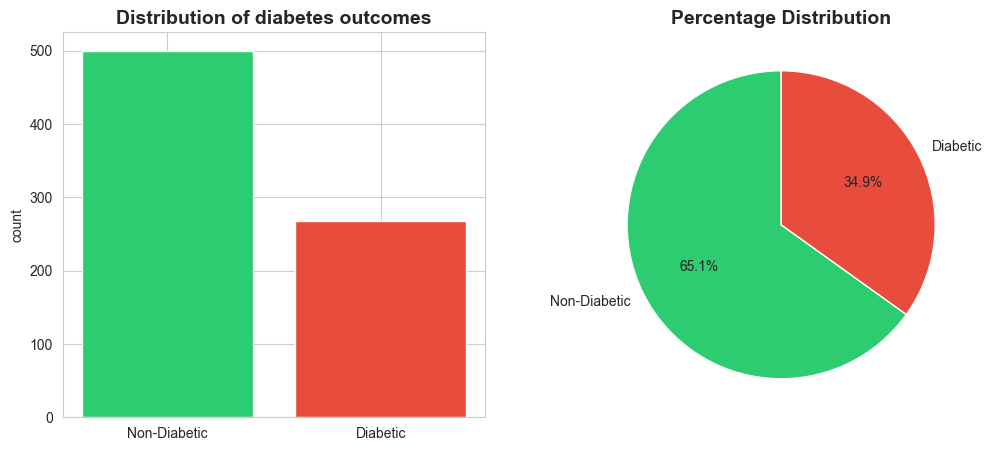

In [615]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
outcome_counts = diabetes_dataset['Outcome'].value_counts()

plt.bar(
    ['Non-Diabetic', 'Diabetic'],
    outcome_counts,
    color=['#2ecc71', '#e74c3c']
)

plt.title(
    'Distribution of diabetes outcomes',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('count')


plt.subplot(1, 2, 2)

plt.pie(
    outcome_counts.values,
    labels=['Non-Diabetic', 'Diabetic'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ecc71', '#e74c3c']
)

plt.title(
    'Percentage Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.show()

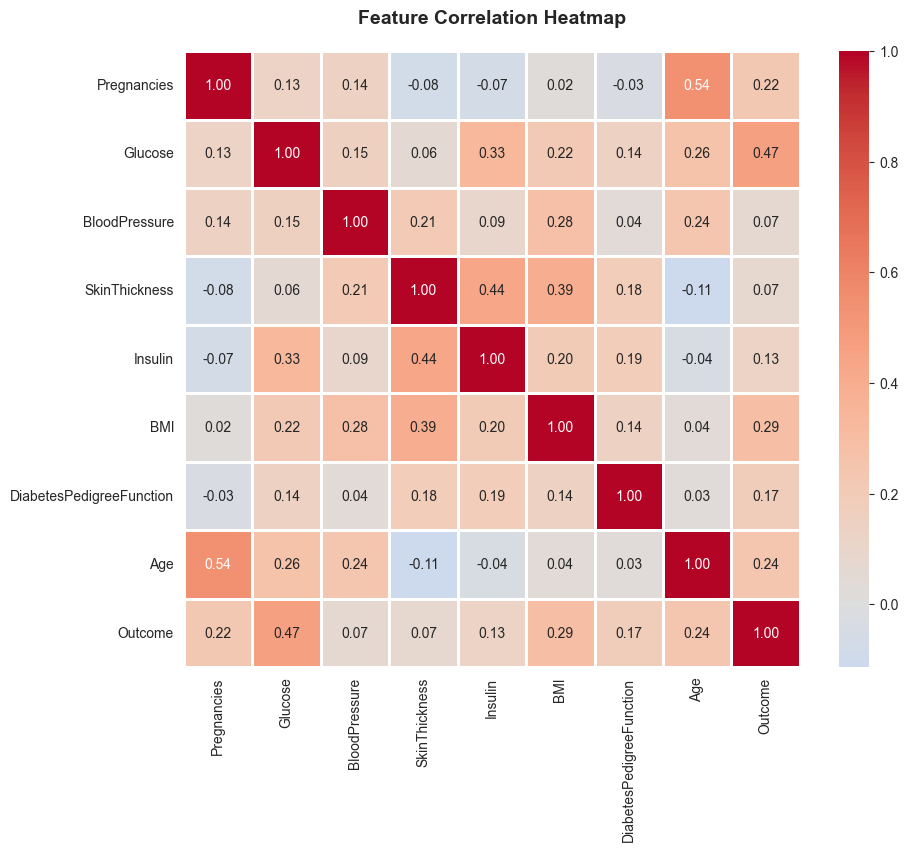

In [616]:
plt.figure(figsize=(10,8))
correlation = diabetes_dataset.corr()
sns.heatmap(correlation,annot=True,cmap='coolwarm',center=0,square=True,linewidth =1,fmt='.2f')
plt.title('Feature Correlation Heatmap',fontsize=14,pad=20,fontweight='bold')
plt.show()

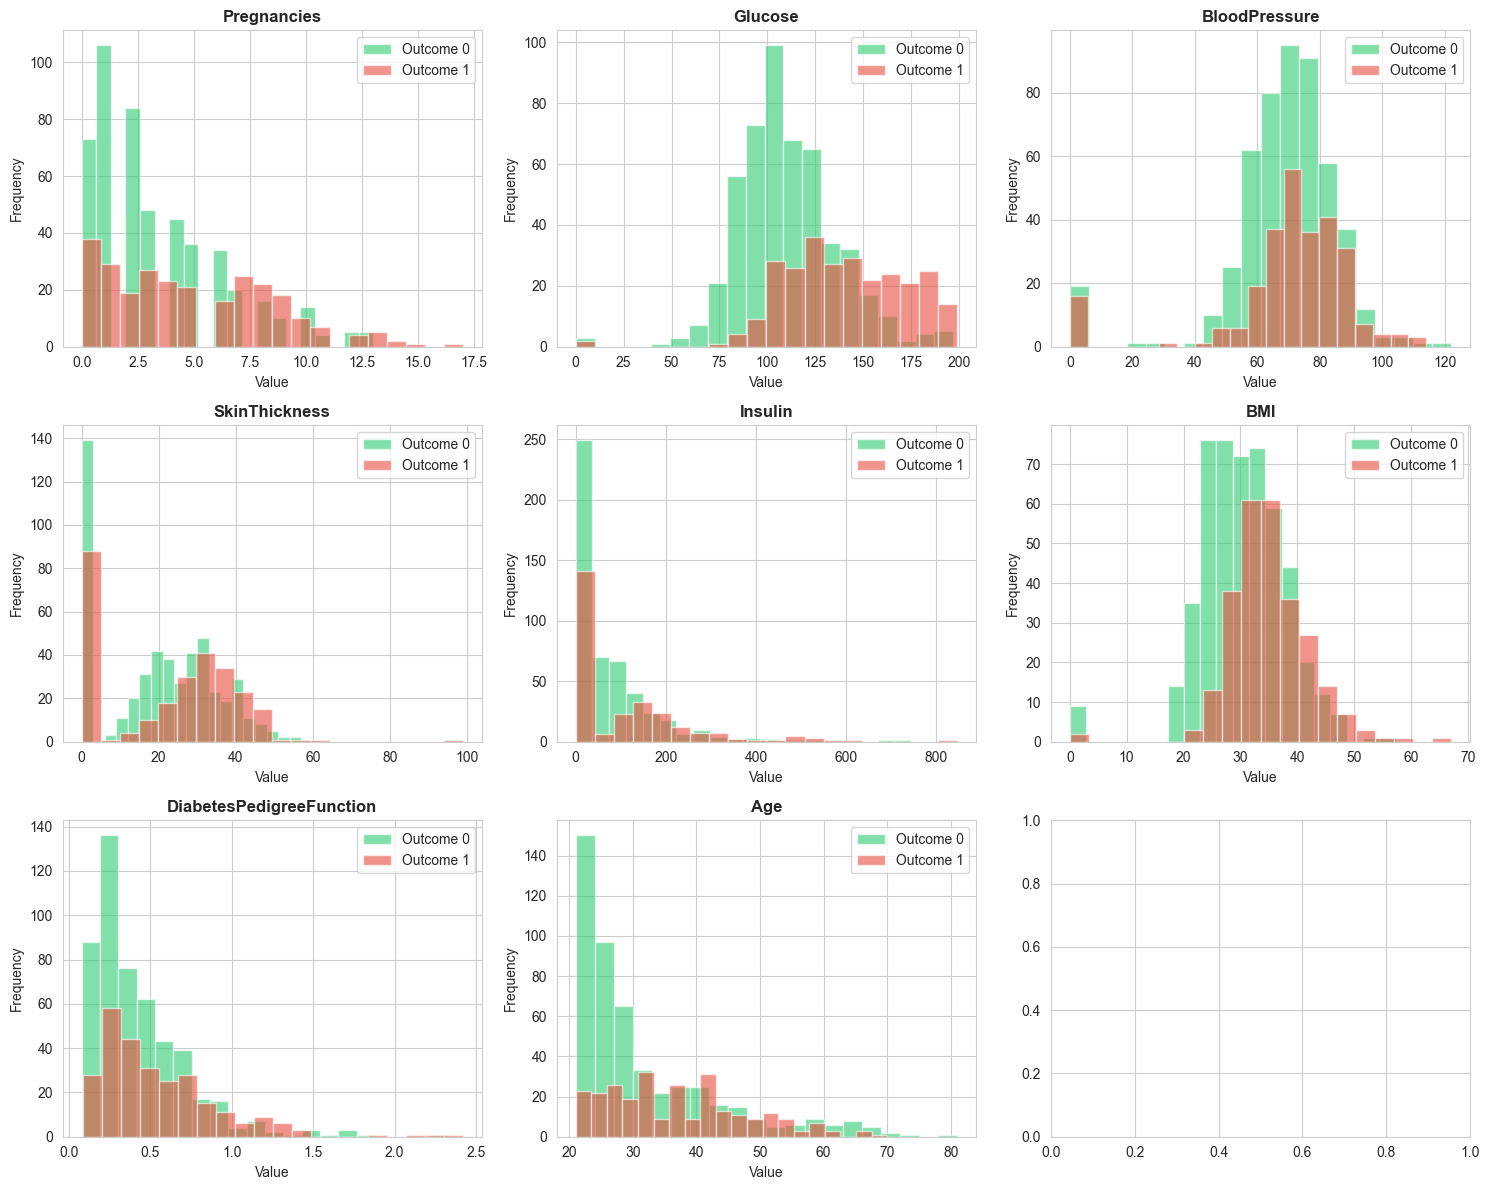

In [617]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

features = diabetes_dataset.columns[:-1]

for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3
    
    for outcome in [0, 1]:
        data = diabetes_dataset[diabetes_dataset['Outcome'] == outcome][feature]
        
        axes[row, col].hist(
            data,
            alpha=0.6,
            bins=20,
            label=f'Outcome {outcome}',
            color=['#2ecc71', '#e74c3c'][outcome]
        )
        
        axes[row, col].set_title(
            feature,
            fontweight='bold'
        )
        
        axes[row, col].set_xlabel('Value')
        axes[row, col].set_ylabel('Frequency')
        axes[row, col].legend()

plt.tight_layout()
plt.show()

In [618]:
X = diabetes_dataset.drop(columns = 'Outcome',axis=1)
Y = diabetes_dataset['Outcome']
print(X)
print(Y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [619]:
scaler = StandardScaler()
scaler.fit(x_train)

,copy,True
,with_mean,True
,with_std,True


In [620]:
import joblib

# Save the trained SVM model
joblib.dump(classifier, 'diabetes_model.pkl')

# Save the StandardScaler
joblib.dump(scaler, 'scaler_svm.pkl')

print("Model saved: diabetes_model.pkl")
print("Scaler saved: scaler_svm.pkl")

Model saved: diabetes_model.pkl
Scaler saved: scaler_svm.pkl


In [621]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(614, 8) (154, 8) (614,) (154,)


In [622]:
classifier = svm.SVC(kernel='linear',probability=True)
classifier.fit(x_train,y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [623]:
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)

training_data_accuracy

0.7833876221498371

In [624]:
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)

test_data_accuracy

0.7727272727272727

In [625]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print(precision, recall, f1)

0.7567567567567568 0.5185185185185185 0.6153846153846154


In [626]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, x_test_prediction)

cm_svm

array([[91,  9],
       [26, 28]])

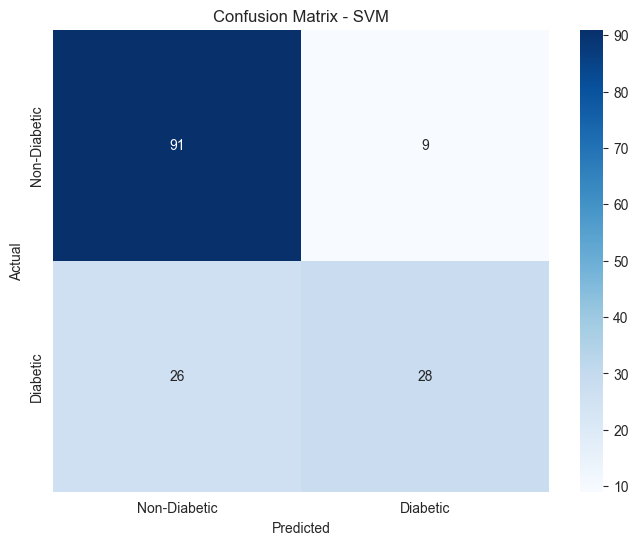

In [627]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')

plt.show()

In [628]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_classifier.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [629]:
x_train_prediction_rf = rf_classifier.predict(x_train)

In [630]:
training_data_accuracy_rf = accuracy_score(
    x_train_prediction_rf,
    y_train
)

training_data_accuracy_rf

1.0

In [631]:
x_train_prediction_rf = rf_classifier.predict(x_train)

In [632]:
training_data_accuracy_rf = accuracy_score(
    x_train_prediction_rf,
    y_train
)

training_data_accuracy_rf

1.0

In [633]:
x_test_prediction_rf = rf_classifier.predict(x_test)

In [634]:
test_data_accuracy_rf = accuracy_score(
    x_test_prediction_rf,
    y_test
)

test_data_accuracy_rf

0.7532467532467533

In [635]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, x_test_prediction_rf)

cm_rf

array([[87, 13],
       [25, 29]])

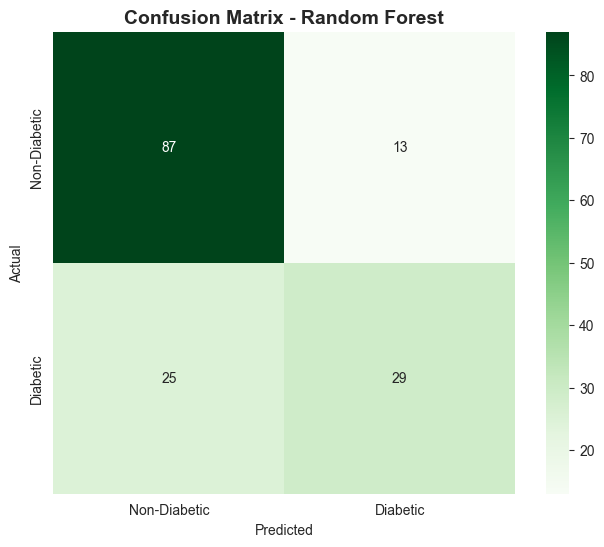

In [636]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    square=True,
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title(
    'Confusion Matrix - Random Forest',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [637]:
print('SVM',test_data_accuracy)
print('Random Forest',test_data_accuracy_rf)

SVM 0.7727272727272727
Random Forest 0.7532467532467533


In [638]:
joblib.dump(classifier,'diabetes_model.pkl')


['diabetes_model.pkl']

In [639]:
input_data = (5, 166, 72, 19, 0, 25.8, 0.587, 51)

input_num_array = np.asarray(input_data)

reshape = input_num_array.reshape(1, -1)

std_data = scaler.transform(reshape)

prediction = classifier.predict(std_data)

print(prediction)

if prediction[0] == 0:
    print('The person is not diabetic')
else:
    print('The person is diabetic')

[0]
The person is not diabetic
